# NB01 — Data Understanding & Audit
## YouTube Trending: ¿Qué señales predicen cuánto dura un video en trending?
### Análisis comparativo México vs Estados Unidos

---

**Objetivo de este notebook:**  
Cargar los datos de MX y US, entender su estructura, auditar la calidad de cada variable y documentar los problemas que deben resolverse en NB02 antes de cualquier análisis o modelado.

**Preguntas que responde este notebook:**
- ¿Qué tan completos son los datos?
- ¿Existen duplicados o anomalías?
- ¿Qué rango temporal cubren?
- ¿Cuál es el comportamiento de las variables de engagement?
- ¿Qué diferencias estructurales hay entre MX y US?

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = {'MX': '#E53935', 'US': '#1E88E5'}  # rojo MX, azul US

DATA_PATH = '../data/raw/'
print('Setup complete ✓')

Setup complete ✓


## 2. Load Data

In [2]:
mx = pd.read_csv(f'{DATA_PATH}MX_youtube_trending_data.csv',
                 parse_dates=['publishedAt', 'trending_date'])
us = pd.read_csv(f'{DATA_PATH}US_youtube_trending_data.csv',
                 parse_dates=['publishedAt', 'trending_date'])

mx['region'] = 'MX'
us['region'] = 'US'

print(f'MX shape : {mx.shape}')
print(f'US shape : {us.shape}')

MX shape : (268598, 17)
US shape : (268787, 17)


## 3. Schema & Dtypes

In [3]:
def schema_summary(df, name):
    info = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notna().sum(),
        'null_count': df.isna().sum(),
        'null_%': (df.isna().mean() * 100).round(2),
        'unique': df.nunique()
    })
    sep = '=' * 55
    print(f'\n{sep}\nDataset: {name}\n{sep}')
    display(info)
    return info

schema_mx = schema_summary(mx, 'MX')
schema_us = schema_summary(us, 'US')


Dataset: MX


,dtype,non_null,null_count,null_%,unique
video_id,object,268598,0,0.00,32442
title,object,268598,0,0.00,33275
publishedAt,"datetime64[ns, UTC]",268598,0,0.00,31964
channelId,object,268598,0,0.00,5065
channelTitle,object,268598,0,0.00,5264
categoryId,int64,268598,0,0.00,15
trending_date,"datetime64[ns, UTC]",268598,0,0.00,1322
tags,object,268598,0,0.00,23544
view_count,int64,268598,0,0.00,254562
likes,int64,268598,0,0.00,142040



Dataset: US


,dtype,non_null,null_count,null_%,unique
video_id,object,268787,0,0.00,47142
title,object,268787,0,0.00,48471
publishedAt,"datetime64[ns, UTC]",268787,0,0.00,46554
channelId,object,268787,0,0.00,8302
channelTitle,object,268787,0,0.00,8543
categoryId,int64,268787,0,0.00,15
trending_date,"datetime64[ns, UTC]",268787,0,0.00,1323
tags,object,268787,0,0.00,32909
view_count,int64,268787,0,0.00,255236
likes,int64,268787,0,0.00,136839


## 4. Temporal Coverage

In [4]:
for name, df in [('MX', mx), ('US', us)]:
    print(f'\n{name} — Trending date range:')
    print(f'  Min : {df["trending_date"].min().date()}')
    print(f'  Max : {df["trending_date"].max().date()}')
    n_days = (df['trending_date'].max() - df['trending_date'].min()).days
    print(f'  Span: {n_days} days ({n_days/365:.1f} years)')
    print(f'  Unique trending days : {df["trending_date"].nunique()}')
    print(f'  Unique videos        : {df["video_id"].nunique()}')
    print(f'  Unique channels      : {df["channelId"].nunique()}')


MX — Trending date range:
  Min : 2020-08-12
  Max : 2024-04-15
  Span: 1342 days (3.7 years)
  Unique trending days : 1322
  Unique videos        : 32442
  Unique channels      : 5065

US — Trending date range:
  Min : 2020-08-12
  Max : 2024-04-15
  Span: 1342 days (3.7 years)
  Unique trending days : 1323
  Unique videos        : 47142
  Unique channels      : 8302


## 5. Volume Over Time

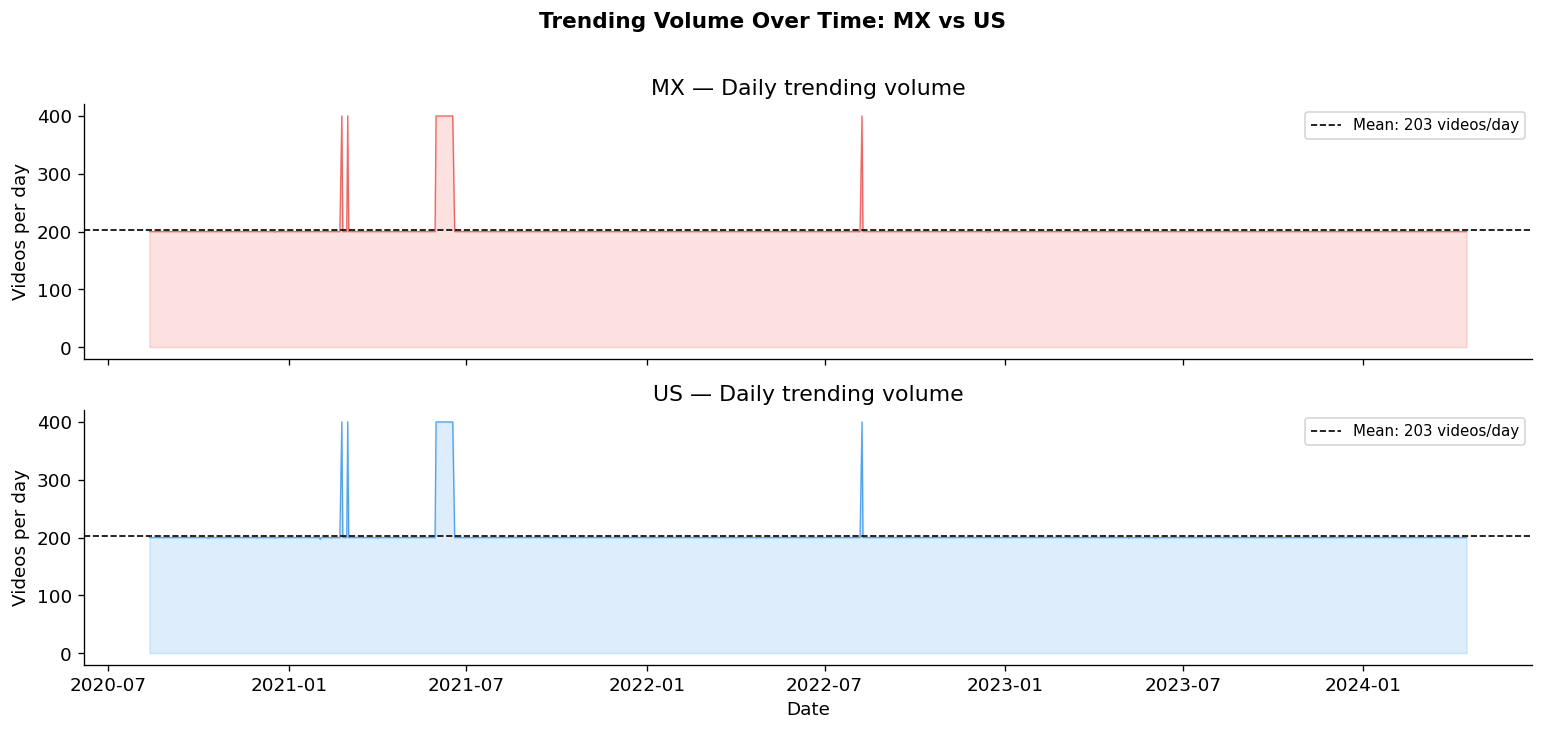

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    daily = df.groupby('trending_date').size()
    ax.plot(daily.index, daily.values, color=PALETTE[name], linewidth=0.8, alpha=0.7)
    ax.fill_between(daily.index, daily.values, alpha=0.15, color=PALETTE[name])
    ax.axhline(daily.mean(), color='black', linestyle='--', linewidth=1,
               label=f'Mean: {daily.mean():.0f} videos/day')
    ax.set_ylabel('Videos per day')
    ax.set_title(f'{name} — Daily trending volume')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Date')
fig.suptitle('Trending Volume Over Time: MX vs US', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/fig_01_volume_over_time.png', bbox_inches='tight')
plt.show()

**Interpretación:**  
Ambos mercados muestran un volumen bastante estable (~200 videos/día), consistente con el diseño del dataset (top-200 diario de YouTube). Los valles visibles corresponden a días sin captura de datos — no son caídas reales de actividad. Esto es importante: **los gaps temporales deben identificarse y excluirse del cálculo de `days_in_trending`** para no inflar artificialmente la duración de videos que cruzaron un gap.

## 6. Duplicate Analysis

In [6]:
for name, df in [('MX', mx), ('US', us)]:
    exact_dups = df.duplicated().sum()
    vid_day_dups = df.duplicated(subset=['video_id', 'trending_date']).sum()
    print(f'{name}:')
    print(f'  Exact duplicate rows        : {exact_dups}')
    print(f'  video_id + trending_date dups: {vid_day_dups}')
    print()

MX:
  Exact duplicate rows        : 70
  video_id + trending_date dups: 4126



US:
  Exact duplicate rows        : 83
  video_id + trending_date dups: 4070



## 7. Engagement Variables — Distribution Audit

In [7]:
eng_cols = ['view_count', 'likes', 'dislikes', 'comment_count']

for name, df in [('MX', mx), ('US', us)]:
    print(f'\n{name} — Engagement statistics:')
    stats = df[eng_cols].describe(percentiles=[.25, .5, .75, .95, .99]).T
    stats['skewness'] = df[eng_cols].skew().values
    stats = stats[['min', '25%', '50%', '75%', '95%', '99%', 'max', 'skewness']]
    display(stats.style.format('{:,.0f}').background_gradient(subset=['skewness'], cmap='Oranges'))


MX — Engagement statistics:


,min,25%,50%,75%,95%,99%,max,skewness
view_count,0,"373,070","822,650","2,011,125","8,246,609","29,396,029","1,406,329,649",34
likes,0,"15,204","41,189","112,589","524,394","1,575,367","16,213,758",13
dislikes,0,0,0,430,"4,253","16,787","879,359",61
comment_count,0,690,"1,730","4,831","30,701","121,753","6,817,451",47



US — Engagement statistics:


,min,25%,50%,75%,95%,99%,max,skewness
view_count,0,"472,541","936,871","2,106,178","8,451,391","32,389,728","1,407,643,634",32
likes,0,"17,963","40,205","98,773","432,264","1,658,352","16,021,534",13
dislikes,0,0,0,467,"4,270","18,919","879,354",50
comment_count,0,"1,280","2,754","6,386","28,619","118,490","6,738,537",42


## 8. Dislikes — Critical Flag (Post Nov 2021)

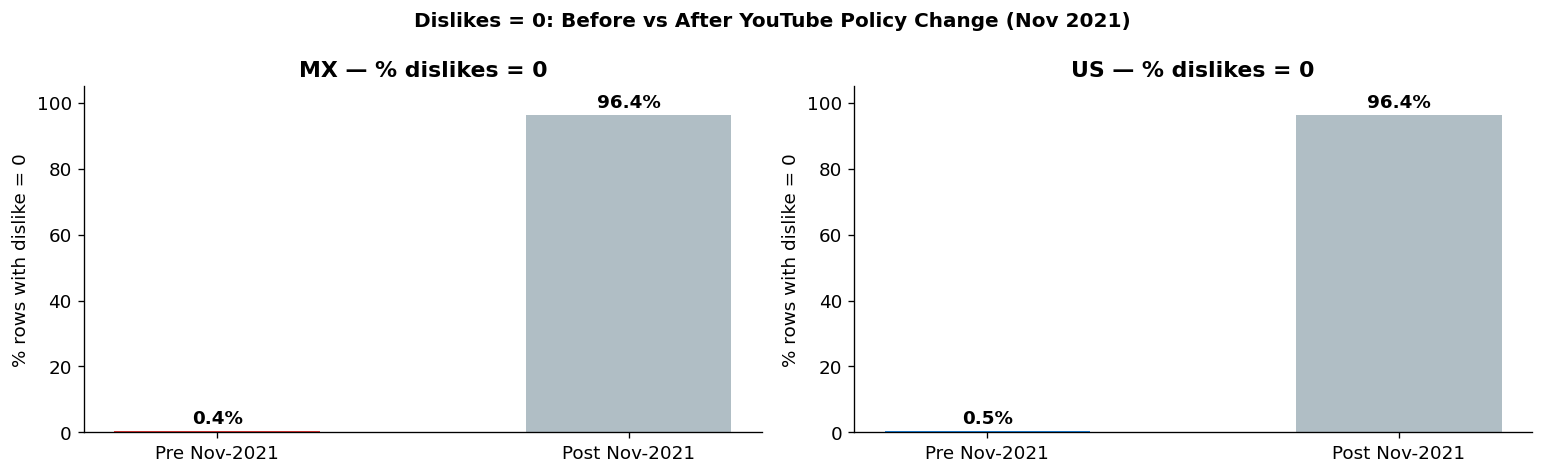

⚠ Conclusion: dislikes is unreliable post Nov-2021 — will be EXCLUDED from modeling.


In [8]:
cutoff = pd.Timestamp('2021-11-10', tz='UTC')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    before = df[df['trending_date'] < cutoff]['dislikes']
    after  = df[df['trending_date'] >= cutoff]['dislikes']
    pct_zero_before = (before == 0).mean() * 100
    pct_zero_after  = (after == 0).mean() * 100

    categories = ['Pre Nov-2021', 'Post Nov-2021']
    values = [pct_zero_before, pct_zero_after]
    bars = ax.bar(categories, values, color=[PALETTE[name], '#B0BEC5'], width=0.5)
    ax.set_title(f'{name} — % dislikes = 0', fontweight='bold')
    ax.set_ylabel('% rows with dislike = 0')
    ax.set_ylim(0, 105)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

fig.suptitle('Dislikes = 0: Before vs After YouTube Policy Change (Nov 2021)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_02_dislikes_policy.png', bbox_inches='tight')
plt.show()

print('⚠ Conclusion: dislikes is unreliable post Nov-2021 — will be EXCLUDED from modeling.')

**Interpretación:**  
La visualización confirma el problema documentado en el diccionario: tras el cambio de política de YouTube en noviembre 2021, prácticamente el 100% de los registros tienen `dislikes = 0`. Esta variable **no puede usarse como feature en el modelo** ya que introduciría una discontinuidad temporal severa. Se excluirá formalmente en NB02.

## 9. Boolean Flags Audit

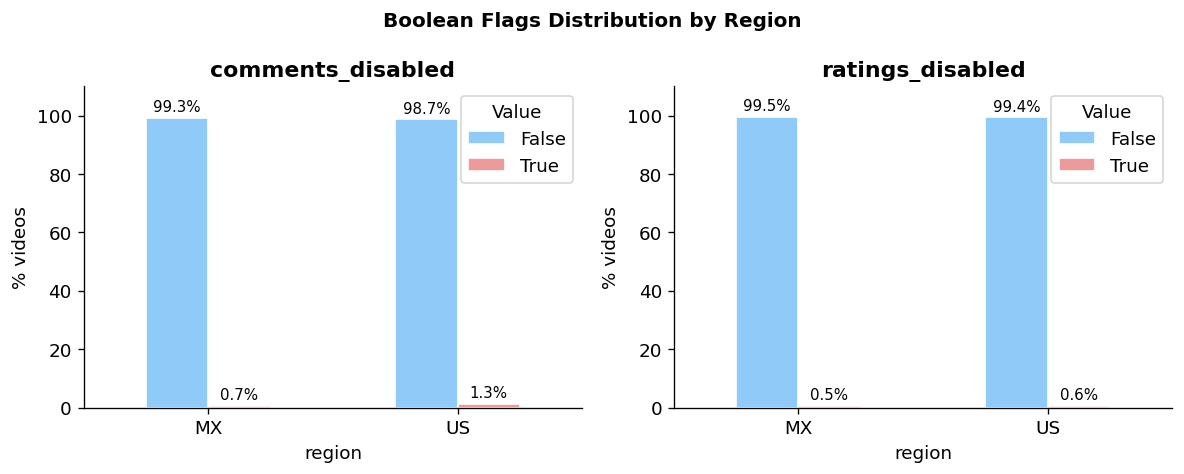

In [9]:
flag_cols = ['comments_disabled', 'ratings_disabled']
combined = pd.concat([mx, us])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, flag_cols):
    counts = combined.groupby(['region', col]).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct.plot(kind='bar', ax=ax, color=['#90CAF9', '#EF9A9A'], edgecolor='white', width=0.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('% videos')
    ax.set_xticklabels(['MX', 'US'], rotation=0)
    ax.legend(['False', 'True'], title='Value')
    ax.set_ylim(0, 110)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=9)

fig.suptitle('Boolean Flags Distribution by Region', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_03_flags_distribution.png', bbox_inches='tight')
plt.show()

## 10. Category JSON — Decode Preview

In [10]:
def load_category_map(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return {
        int(item['id']): item['snippet']['title']
        for item in data['items']
    }

cat_mx = load_category_map(f'{DATA_PATH}MX_category_id.json')
cat_us = load_category_map(f'{DATA_PATH}US_category_id.json')

print(f'MX categories ({len(cat_mx)}): {cat_mx}')
print(f'\nUS categories ({len(cat_us)}): {cat_us}')

# Check coverage
mx_ids = set(mx['categoryId'].dropna().astype(int).unique())
us_ids = set(us['categoryId'].dropna().astype(int).unique())
print(f'\nMX category IDs in data not in JSON: {mx_ids - set(cat_mx.keys())}')
print(f'US category IDs in data not in JSON: {us_ids - set(cat_us.keys())}')

MX categories (31): {1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/Adventure', 33: 'Classics', 34: 'Comedy', 35: 'Documentary', 36: 'Drama', 37: 'Family', 38: 'Foreign', 39: 'Horror', 40: 'Sci-Fi/Fantasy', 41: 'Thriller', 42: 'Shorts', 43: 'Shows', 44: 'Trailers'}

US categories (32): {1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism', 30: 'Movies', 31: 'Anime/Animation', 32: 'A

## 11. Top Channels — Preliminary View

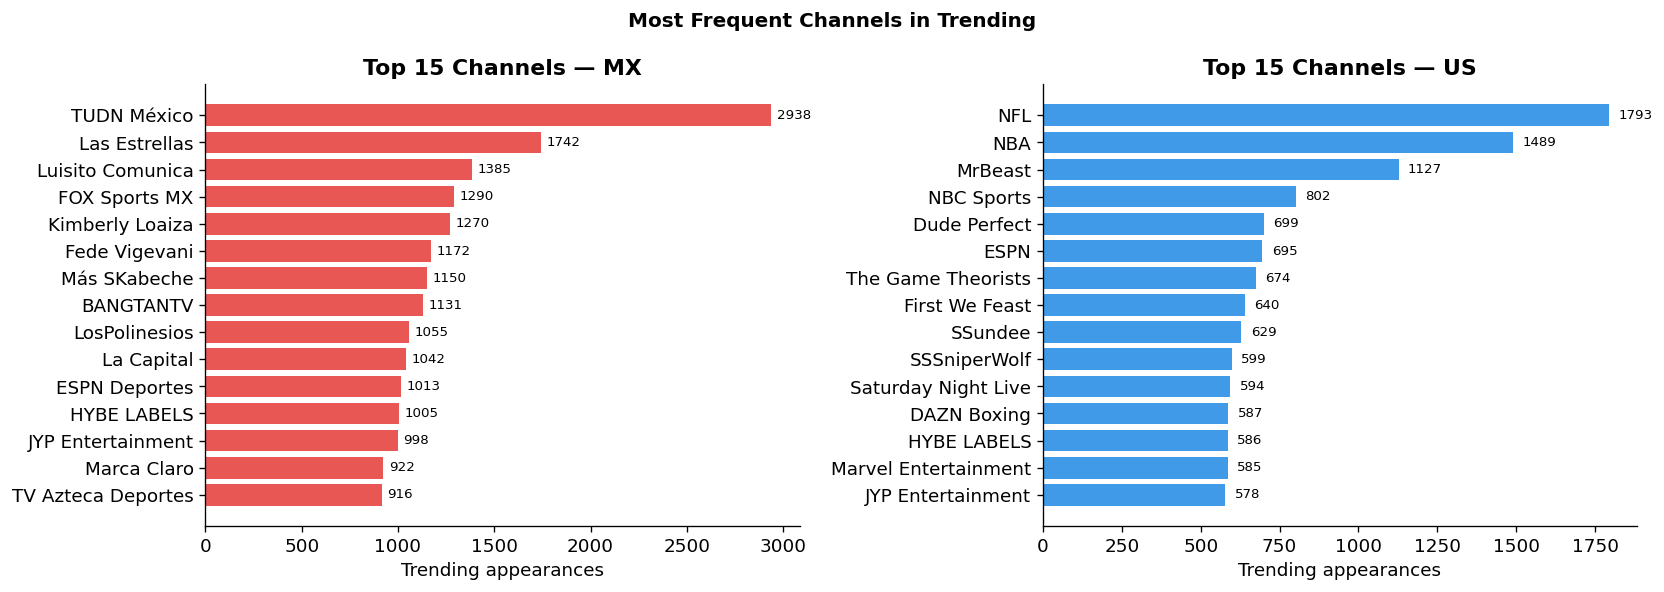

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('MX', mx), ('US', us)]):
    top = df['channelTitle'].value_counts().head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=PALETTE[name], alpha=0.85)
    ax.set_xlabel('Trending appearances')
    ax.set_title(f'Top 15 Channels — {name}', fontweight='bold')
    for i, v in enumerate(top.values[::-1]):
        ax.text(v + 30, i, str(v), va='center', fontsize=8)

plt.suptitle('Most Frequent Channels in Trending', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_04_top_channels.png', bbox_inches='tight')
plt.show()

## 12. Audit Summary — Issues to Fix in NB02

| # | Issue | Severity | Action in NB02 |
|---|-------|----------|----------------|
| 1 | `dislikes` inutilizable post Nov-2021 | 🔴 Alta | Excluir del modelado |
| 2 | Gaps temporales en trending_date | 🟡 Media | Detectar gaps antes de calcular `days_in_trending` |
| 3 | `view_count`, `likes`, `comment_count` con sesgo extremo (skew >> 1) | 🟡 Media | Transformación log en modelado |
| 4 | `categoryId` requiere decodificación con JSON | 🟢 Baja | Merge con diccionario de categorías |
| 5 | Un mismo `video_id` aparece múltiples días (es correcto, no es duplicado) | 🟢 Info | Tener en cuenta al construir el target |
| 6 | `tags` en formato string delimitado por `\|` | 🟢 Baja | Parsear para feature de `tag_count` |
| 7 | `description` puede estar vacía | 🟢 Baja | Flag binario `has_description` |

In [12]:
print('NB01 complete. All findings documented.')
print('Next: NB02 — Feature Engineering & Target Construction')

NB01 complete. All findings documented.
Next: NB02 — Feature Engineering & Target Construction
